In [1]:
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("hotel_bookings.csv")

df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [3]:
print(df.shape)

df.info()

df.describe()

df.isnull().sum()

(119390, 32)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  mea

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

In [4]:
# Remove duplicates
df = df.drop_duplicates()

# Fill missing values
df["children"] = df["children"].fillna(0)
df["country"] = df["country"].fillna("Unknown")
df["agent"] = df["agent"].fillna(0)
df["company"] = df["company"].fillna(0)

In [5]:
price_levels = [3000, 4000, 5000, 6000, 7000]

print(price_levels)

[3000, 4000, 5000, 6000, 7000]


In [6]:
booking_probability = []

for value in df["is_canceled"]:
    
    if value == 0:
        booking_probability.append(np.random.uniform(0.7,1.0))
        
    else:
        booking_probability.append(np.random.uniform(0.1,0.5))

df["booking_probability"] = booking_probability

In [7]:
df[["is_canceled","booking_probability"]].head()

,is_canceled,booking_probability
0,0,0.908644
1,0,0.852320
2,0,0.906878
3,0,0.788090
4,0,0.814785


In [8]:
class FixedPriceAgent:
    
    def choose_price(self):
        
        return 5000

In [9]:
agent = FixedPriceAgent()

print(agent.choose_price())

5000


In [10]:
class TimeDiscountAgent:
    
    def choose_price(self, days_left):
        
        if days_left > 20:
            return 7000
        
        elif days_left > 10:
            return 5000
        
        else:
            return 3000

In [11]:
agent = TimeDiscountAgent()

print(agent.choose_price(28))

print(agent.choose_price(15))

print(agent.choose_price(5))

7000
5000
3000


In [12]:
def revenue(price, booked):
    
    if booked:
        return price
    
    else:
        return 0

In [13]:
print(revenue(5000,True))

print(revenue(5000,False))

5000
0


In [14]:
inventory = 30

days = 30

total_revenue = 0

agent = FixedPriceAgent()

for day in range(days):

    if inventory == 0:
        break

    price = agent.choose_price()

    booked = np.random.rand() < 0.60

    if booked:

        inventory -= 1

        total_revenue += price

print("Revenue =", total_revenue)

Revenue = 100000


In [15]:
inventory = 30

days = 30

total_revenue = 0

agent = TimeDiscountAgent()

for day in range(days):

    if inventory == 0:
        break

    days_left = days - day

    price = agent.choose_price(days_left)

    booked = np.random.rand() < 0.60

    if booked:

        inventory -= 1

        total_revenue += price

print("Revenue =", total_revenue)

Revenue = 100000


In [16]:
fixed_revenues = []

discount_revenues = []

In [17]:
for episode in range(100):

    # Fixed Price

    inventory = 30
    revenue_fixed = 0

    agent = FixedPriceAgent()

    for day in range(30):

        if inventory == 0:
            break

        booked = np.random.rand() < 0.60

        if booked:

            inventory -= 1

            revenue_fixed += agent.choose_price()

    fixed_revenues.append(revenue_fixed)

    # Time Discount

    inventory = 30
    revenue_discount = 0

    agent = TimeDiscountAgent()

    for day in range(30):

        if inventory == 0:
            break

        booked = np.random.rand() < 0.60

        if booked:

            inventory -= 1

            revenue_discount += agent.choose_price(30-day)

    discount_revenues.append(revenue_discount)

In [18]:
print("Average Fixed Revenue")

print(np.mean(fixed_revenues))

print()

print("Average Discount Revenue")

print(np.mean(discount_revenues))

Average Fixed Revenue
89700.0

Average Discount Revenue
90660.0


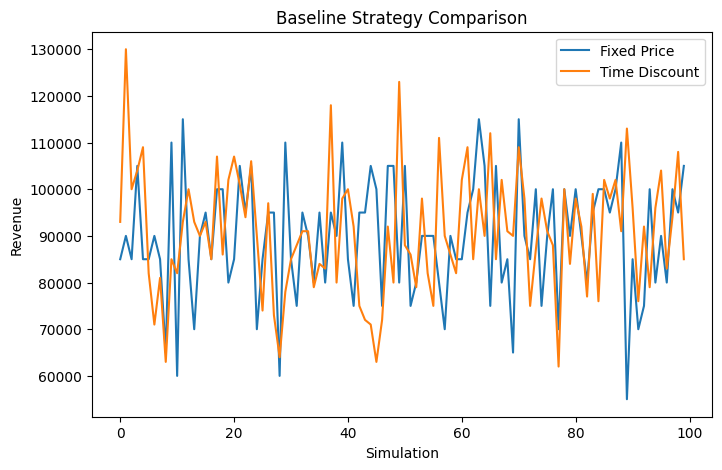

In [19]:
plt.figure(figsize=(8,5))

plt.plot(fixed_revenues,label="Fixed Price")

plt.plot(discount_revenues,label="Time Discount")

plt.xlabel("Simulation")

plt.ylabel("Revenue")

plt.title("Baseline Strategy Comparison")

plt.legend()

plt.show()

In [20]:
inventory_states = 31

day_states = 31

actions = 5

Q = np.zeros((inventory_states, day_states, actions))

print(Q.shape)

(31, 31, 5)


In [21]:
alpha = 0.1

gamma = 0.95

epsilon = 0.2

In [22]:
def choose_action(state):

    inventory, day = state

    if np.random.rand() < epsilon:

        return np.random.randint(actions)

    else:

        return np.argmax(Q[inventory,day])

In [23]:
def get_reward(price, booked):

    if booked:

        return price

    else:

        return 0

In [24]:
episodes = 1000

for episode in range(episodes):

    inventory = 30

    day = 30

    while inventory > 0 and day > 0:

        state = (inventory, day)

        action = choose_action(state)

        price = price_levels[action]

        booking_probability = max(0.1, 1 - (price - 3000) / 5000)

        booked = np.random.rand() < booking_probability

        reward = get_reward(price, booked)

        if booked:
            next_inventory = inventory - 1
        else:
            next_inventory = inventory

        next_day = day - 1

        next_state = (next_inventory, next_day)

        Q[inventory, day, action] = Q[inventory, day, action] + alpha * (
            reward + gamma * np.max(Q[next_inventory, next_day]) - Q[inventory, day, action]
        )

        inventory = next_inventory
        day = next_day

In [25]:
np.save("q_table.npy",Q)

print("Q Table Saved Successfully")

Q Table Saved Successfully
